In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('/Users/garvit/Desktop/NestWise/Clean Data/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,2400.0,Super Built up area 2400(222.97 sq.m.)Carpet a...,4.0,5.0,3+,6.0,East,Moderately Old,2400.0,NaN,1850.0,0,1,0,0,0,1,95
1,flat,capital residences 360,sector 70a,1.69,8552.0,1976.0,Super Built up area 1976(183.58 sq.m.)Built Up...,3.0,3.0,3+,8.0,North-East,New Property,1976.0,1900.0,1650.0,0,1,0,0,0,0,165
2,flat,emaar palm premier,sector 77,2.10,10500.0,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3.0,4.0,3+,11.0,NaN,New Property,2000.0,1600.0,1500.0,0,1,0,0,0,1,129
3,flat,m3m merlin3.,sector 67,2.65,12945.0,2047.0,Super Built up area 2047(190.17 sq.m.)Built Up...,3.0,3.0,3,0.0,North-East,Relatively New,2047.0,1900.0,1700.0,0,0,0,0,1,1,174
4,flat,dnha group housing society,manesar,0.75,4518.0,1660.0,Super Built up area 1660(154.22 sq.m.),3.0,2.0,2,5.0,NaN,Moderately Old,1660.0,NaN,NaN,0,0,0,0,0,0,0


Outlier Detection : known about the distribution of numerical col, check if they have a normal distribution or skewed distribution

# Price And Price/sqft

In [5]:
df['price'].value_counts()

price
1.25     80
1.50     65
1.20     64
0.90     64
1.10     62
         ..
4.67      1
2.54      1
2.64      1
2.63      1
11.58     1
Name: count, Length: 473, dtype: int64

In [7]:
df['price'].shape

(3691,)

In [9]:
df['price'].describe()

count    3663.000000
mean        2.532449
std         2.979719
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

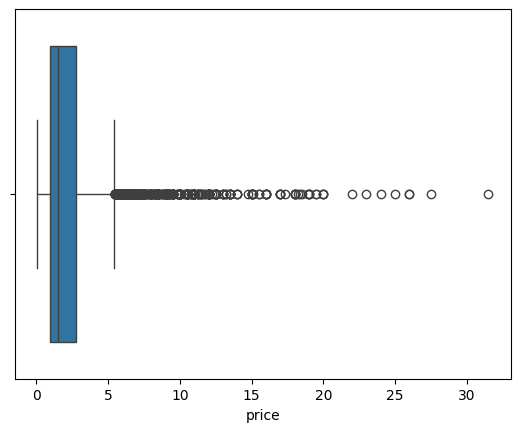

In [8]:
sns.boxplot(x = df['price'])

In [10]:
# calculate the IQR for the 'price' columns

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[ (df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [ ]:
outliers.sort_values('price',ascending=False).head(20) # some properties are geniun whereas some are outlier 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3290,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7.0,9.0,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,2,74
2050,house,independent,sector 43,27.50,24366.0,11290.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
2900,house,dlf city plots,sector 26,26.00,57206.0,4540.0,Plot area 505(422.24 sq.m.),6.0,7.0,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
716,house,independent,sector 26,26.00,82540.0,315.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16.0,16.0,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
1915,house,suncity township,sector 54,25.00,31111.0,8040.0,Plot area 1000(836.13 sq.m.),4.0,4.0,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
3336,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5.0,5.0,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
1123,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4.0,4.0,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,1,145
972,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5.0,6.0,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
2856,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
2965,house,luxury dlf city floors,sector 26,20.00,48889.0,4090.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31


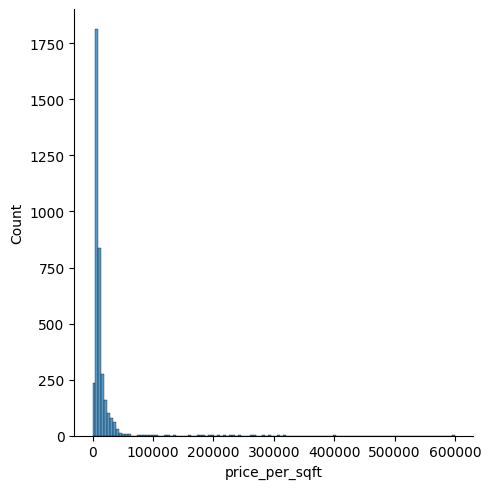

In [ ]:
sns.displot(df['price_per_sqft']) # right skewed 

<Axes: xlabel='price_per_sqft'>

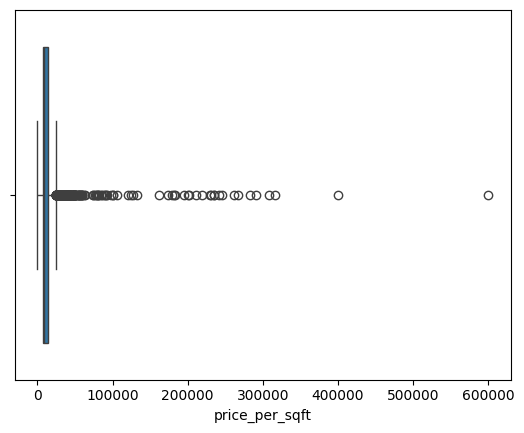

In [13]:
sns.boxplot(x=df['price_per_sqft'])

In [14]:
df[df['area'] < 1000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,house,surendra homes dayaindependentd colony,sector 6,0.75,15625.0,48.0,Built Up area: 480 (44.59 sq.m.),4.0,4.0,2,1.0,NaN,Undefined,NaN,480.0,NaN,0,0,0,0,0,0,0
13,flat,bestech park view residency3.,sector 2,0.56,8553.0,655.0,Carpet area: 650 (60.39 sq.m.),1.0,1.0,2,7.0,South-West,Moderately Old,NaN,NaN,650.00,0,0,0,0,0,0,92
14,flat,rof ananda,sector 95,0.25,6578.0,380.0,Super Built up area 380(35.3 sq.m.),1.0,1.0,1,4.0,NaN,New Property,380.0,NaN,NaN,0,0,0,0,0,0,0
21,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2.0,2.0,2,11.0,North-West,New Property,NaN,NaN,728.00,1,0,0,0,0,0,82
29,house,emaar mgf marbella,sector 66,19.00,31666.0,600.0,Plot area 9000(836.13 sq.m.)Carpet area: 6000 ...,5.0,6.0,3+,3.0,North-East,Relatively New,NaN,NaN,6000.00,0,1,1,1,0,1,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,flat,mvn athens3.,sohna road road,0.27,5901.0,458.0,Carpet area: 457.52 (42.5 sq.m.),2.0,2.0,1,0.0,NaN,Relatively New,NaN,NaN,457.52,0,0,0,0,0,1,69
3795,house,eros rosewood villas,sector 49,2.75,178571.0,15.0,Plot area 154(14.31 sq.m.)Carpet area: 1650 sq...,3.0,3.0,1,2.0,North-West,Old Property,NaN,NaN,1650.00,0,0,0,0,1,1,80
3798,flat,my home,new sector 2,0.22,4400.0,500.0,Carpet area: 500 (46.45 sq.m.),2.0,2.0,1,1.0,NaN,New Property,NaN,NaN,500.00,0,0,0,0,0,1,0
3799,house,independent,sector 37d,1.16,7539.0,154.0,Built Up area: 1535 (142.61 sq.m.),1.0,1.0,0,1.0,NaN,Undefined,NaN,1535.0,NaN,0,0,0,0,0,0,0


In [16]:
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_sqft = df[ (df['price_per_sqft'] < lower_bound ) | (df['price_per_sqft'] > upper_bound)]

num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [17]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x * 9 if x < 1000 else x)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/1803300022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x : x * 9 if x < 1000 else x)


In [19]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [21]:
outliers_sqft['price_per_sqft'].describe()

count       354.000000
mean      39534.533898
std       38164.361555
min        2778.000000
25%       26806.250000
50%       32407.000000
75%       39010.500000
max      350877.000000
Name: price_per_sqft, dtype: float64

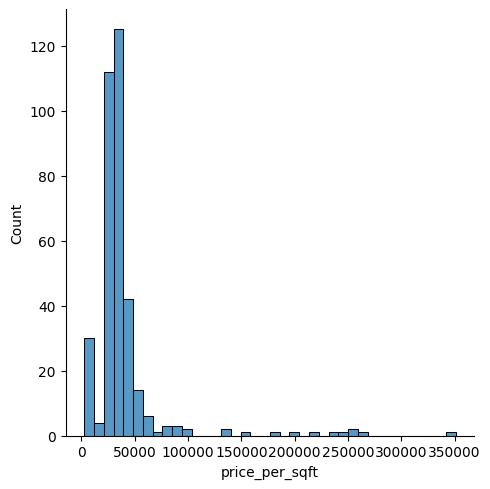

In [22]:
sns.displot(outliers_sqft['price_per_sqft'])

In [23]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft'>

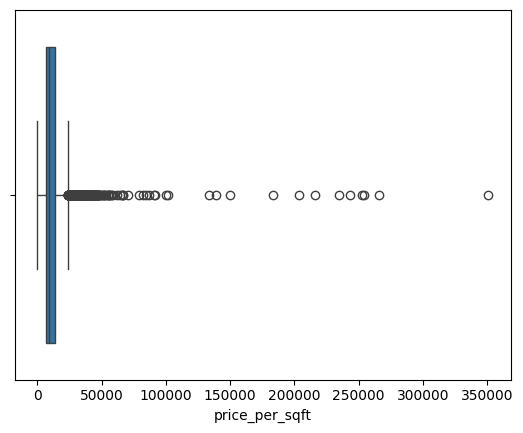

In [24]:
sns.boxplot(x=df['price_per_sqft'])

In [27]:
df[df['price_per_sqft'] > 50000].shape

(38, 23)

In [28]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

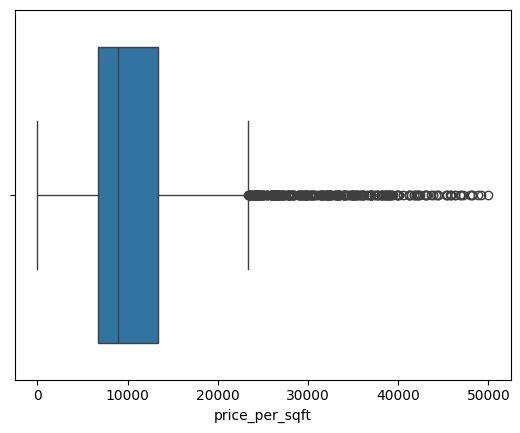

In [30]:
sns.boxplot(x=df['price_per_sqft'])

# Area

<Axes: xlabel='area'>

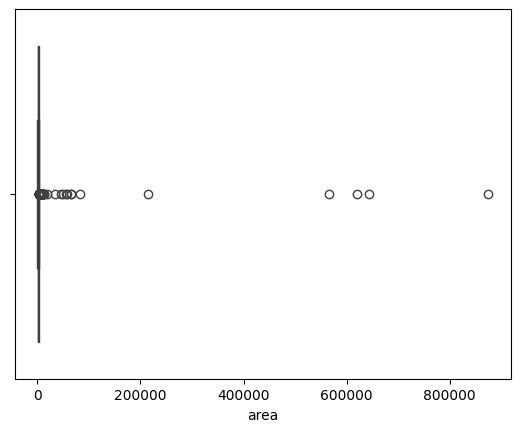

In [32]:
sns.boxplot(x=df['area'])

In [33]:
df['area'].describe()

count      3625.000000
mean       2745.984828
std       23187.340012
min          15.000000
25%        1150.000000
50%        1670.000000
75%        2250.000000
max      875000.000000
Name: area, dtype: float64

In [34]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
249,flat,signature the roselia3.,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2.0,2.0,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
375,flat,hcbs sports ville3.,sohna road road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2.0,2.0,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
962,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2.0,2.0,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
2326,house,independent,sector 50,5.00,232.0,215520.0,Plot area 2(1011.71 sq.m.),6.0,5.0,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,1,0
3632,flat,ramsons kshitij3.,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2.0,2.0,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65


In [35]:
df = df[df['area'] < 100000]

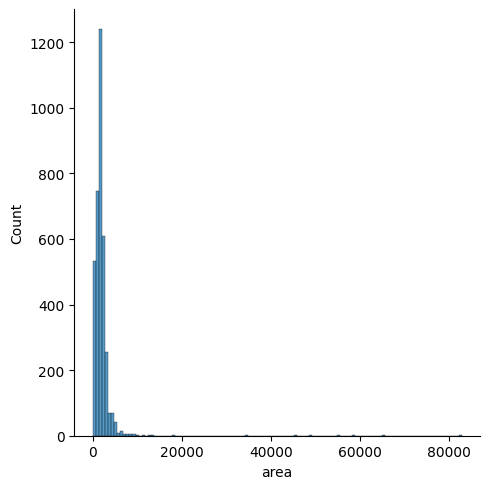

In [36]:
sns.displot(df['area'])

<Axes: xlabel='area'>

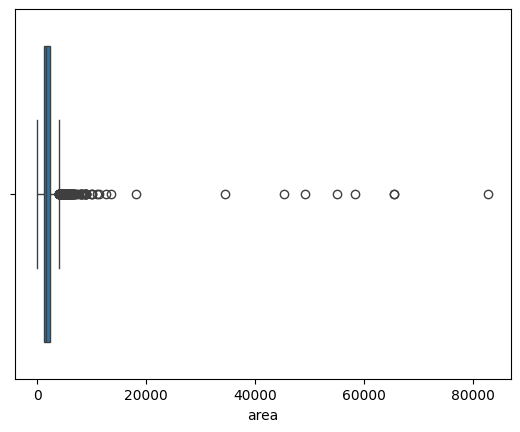

In [37]:
sns.boxplot(x=df['area'])

In [ ]:
df[df['area'] > 10000].sort_values('area',ascending=False)
# 3179, 2773, 3549, 1928, 923, 286, 3217, 3432, 869

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3179,house,ganpati heights apartment,sector 13,1.25,151.0,82780.0,Plot area 115(7692.86 sq.m.),10.0,6.0,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2773,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2.0,2.0,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
3549,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3.0,2.0,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
1928,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
923,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2.0,2.0,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
286,flat,signature the serenas,sohna road road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1.0,1.0,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
3217,flat,ramsons kshitij3.,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2.0,2.0,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33
3432,flat,rof ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1.0,1.0,1,13.0,North,Relatively New,NaN,NaN,34401.00,0,0,0,0,0,0,68
2427,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44
869,house,independent,sector 4,0.85,630.0,13490.0,Plot area 1500(1254.19 sq.m.),3.0,3.0,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0


In [39]:
df.drop(index=[3179, 2773, 3549, 1928, 923, 286, 3217, 3432, 869],inplace=True)

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/1642699708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index=[3179, 2773, 3549, 1928, 923, 286, 3217, 3432, 869],inplace=True)


In [40]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2427,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44
1766,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3.0,3.0,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
2050,house,independent,sector 43,27.50,24366.0,11290.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
1918,flat,m3m golfestate4.,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,0,60


flat,godrej air,sector 85,2.5,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,"pooja room,study room,others",16.0,North-East,Mar 2024,"['Sapphire 83 Mall', 'Sector 86 Road', 'Dwarka Expy', 'Euro International School', 'Sushant University', 'Shri Balaji’s Multispeciality Hospital', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']","['4 Wardrobe', '1 Water Purifier', '4 Fan', '1 Stove', '1 Modular Kitchen', '4 AC', '2 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"


In [41]:
df.loc[2427,'area'] = 1812
df.loc[1766,'area'] = 1175


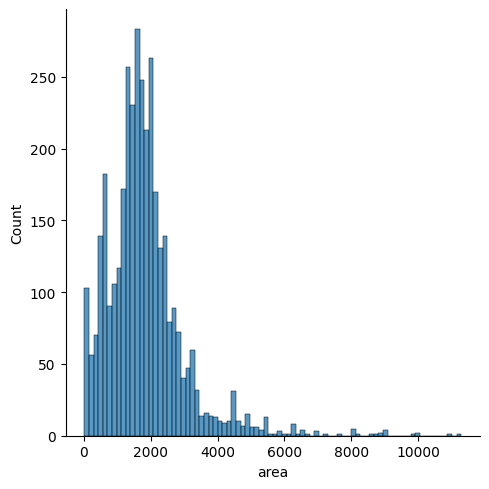

In [42]:
sns.displot(df['area'])

<Axes: xlabel='area'>

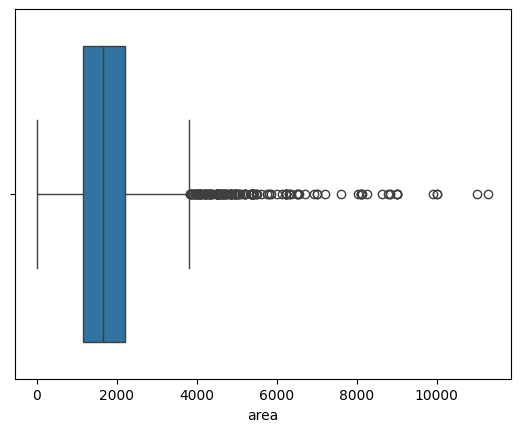

In [43]:
sns.boxplot(x=df['area'])

# bedroom

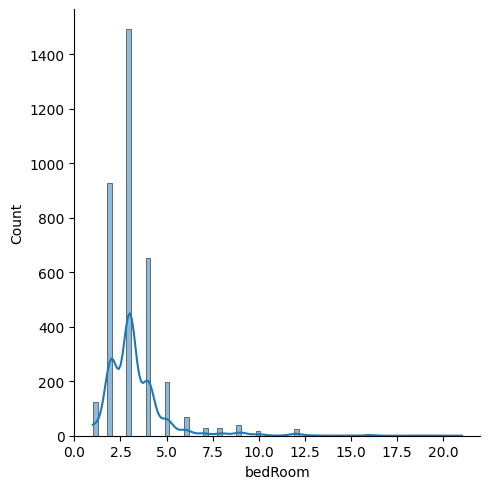

In [46]:
sns.displot(df['bedRoom'],kde=True)

<Axes: xlabel='bedRoom'>

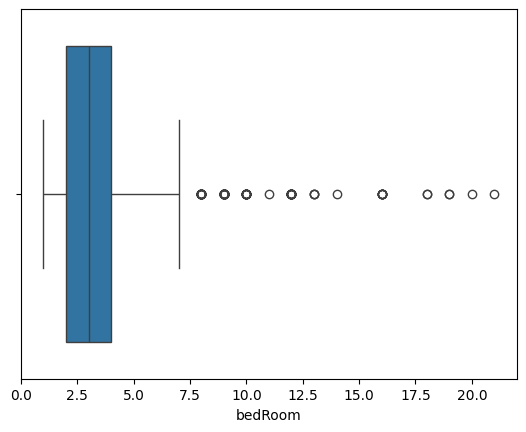

In [47]:
sns.boxplot(x=df['bedRoom'])

In [48]:
df['bedRoom'].describe()

count    3611.000000
mean        3.316533
std         1.800523
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [49]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2573,house,independent,sector 54,5.00,43103.0,1160.0,Plot area 129(107.86 sq.m.),21.0,21.0,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,2,49
2525,house,independent,sector 43,4.50,39130.0,1150.0,Plot area 128(107.02 sq.m.),20.0,20.0,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,2,22
3755,house,independent,sector 17a,3.87,5160.0,750.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19.0,17.0,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
1488,house,independent,sector 17a,3.93,24214.0,162.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19.0,17.0,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
3486,house,private house,sector 55,7.05,47000.0,1500.0,Plot area 167(139.63 sq.m.),18.0,18.0,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,2,57
1802,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18.0,18.0,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,2,70
2965,house,luxury dlf city floors,sector 26,20.00,48900.0,4090.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31
2786,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0,1,0,1,0,1,49
1941,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16.0,18.0,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,1,49
738,house,independent,sector 11,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16.0,16.0,3+,4.0,South,Relatively New,NaN,1800.0,NaN,0,0,0,0,0,1,20


In [50]:
df = df[df['bedRoom'] <= 10]

/var/folders/gb/0twhhzk95yng3hgbcm16f5ph0000gn/T/ipykernel_51511/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

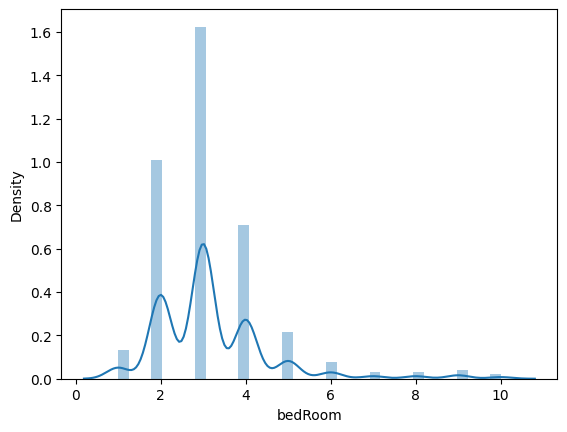

In [51]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

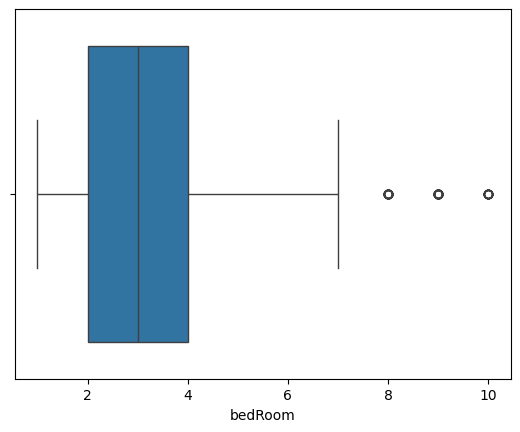

In [52]:
sns.boxplot(x=df['bedRoom'])

# bathroom

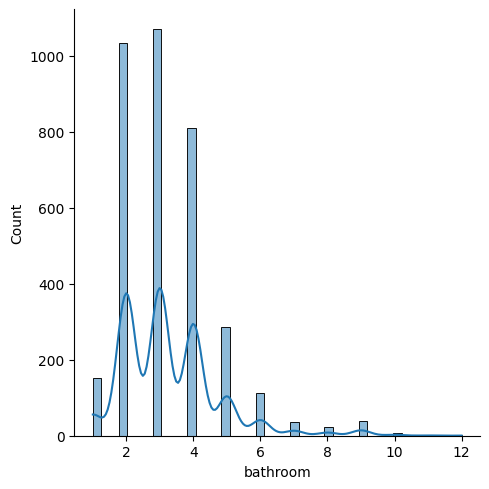

In [54]:
sns.displot(df['bathroom'],kde=True)

In [55]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1883,house,adani brahma samsara,sector 60,18.02,31334.0,5751.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,1,146
3482,house,independent,sector 24,11.00,32079.0,3429.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,1,39
3786,house,independent,sector 39,7.00,10000.0,700.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10.0,11.0,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,1,38
